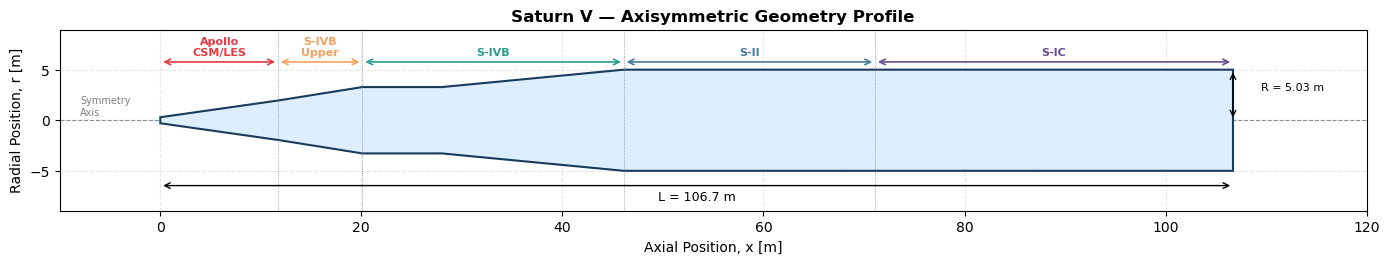

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Saturn V profile points (x, r) from Gmsh file
profile = [
    (0.0,   0.0),   # nose tip (axis)
    (0.0,   0.3),   # LES tip edge
    (11.7,  1.96),  # Apollo base
    (20.1,  3.30),  # S-IVB top
    (28.0,  3.30),  # S-IVB bottom
    (46.1,  5.03),  # S-II top
    (71.1,  5.03),  # S-IC top
    (106.7, 5.03),  # base edge
    (106.7, 0.0),   # base centre (axis)
]

x = [p[0] for p in profile]
r = [p[1] for p in profile]

# Mirror for full body view
x_full = x + x[::-1]
r_full = r + [-ri for ri in r[::-1]]

fig, ax = plt.subplots(figsize=(14, 5))

# Fill body
ax.fill(x_full, r_full, color='#DDEEFF', edgecolor='#1A3A5C', linewidth=1.5, zorder=2)

# Axis line
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', zorder=1)

# Stage annotation lines and labels
stages = [
    (0.0,   11.7,  'Apollo\nCSM/LES'),
    (11.7,  20.1,  'S-IVB\nUpper'),
    (20.1,  46.1,  'S-IVB'),
    (46.1,  71.1,  'S-II'),
    (71.1,  106.7, 'S-IC'),
]

colors = ['#E63946', '#F4A261', '#2A9D8F', '#457B9D', '#6A4C93']

for i, (x0, x1, label) in enumerate(stages):
    xmid = (x0 + x1) / 2
    # vertical divider
    if i > 0:
        ax.axvline(x0, color='gray', linewidth=0.6, linestyle=':', zorder=3)
    # label above
    ax.text(xmid, 6.2, label, ha='center', va='bottom', fontsize=8,
            color=colors[i], fontweight='bold')
    # bracket line
    ax.annotate('', xy=(x0, 5.8), xytext=(x1, 5.8),
                arrowprops=dict(arrowstyle='<->', color=colors[i], lw=1.2))

# Dimension annotations
ax.annotate('', xy=(0, -6.5), xytext=(106.7, -6.5),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.0))
ax.text(53.35, -8, 'L = 106.7 m', ha='center', fontsize=9)

ax.annotate('', xy=(106.7, 0), xytext=(106.7, 5.03),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.0))
ax.text(109.5, 3, 'R = 5.03 m', ha='left', fontsize=8)

# Axis labels
ax.set_xlabel('Axial Position, x [m]', fontsize=10)
ax.set_ylabel('Radial Position, r [m]', fontsize=10)
ax.set_title('Saturn V — Axisymmetric Geometry Profile', fontsize=12, fontweight='bold')

ax.set_xlim(-10, 120)
ax.set_ylim(-9, 9)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.3)

# Symmetry label
ax.text(-8, 0.3, 'Symmetry\nAxis', fontsize=7, color='gray', va='bottom')

plt.tight_layout()
plt.savefig('saturn_v_geometry.png', dpi=300, bbox_inches='tight')


In [8]:
"""
Taylor-Maccoll Solver for Saturn V Validation
Finds theoretical shock angle for inviscid axisymmetric supersonic flow over a cone.
"""

import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

MACH    = 9.0       # Freestream Mach number
GAMMA   = 1.4       # Ratio of specific heats (calorically perfect gas)
THETA_C = 8.07      # Equivalent cone half-angle (degrees) — Saturn V nose

def oblique_shock(M1, beta_deg):
    """
    Given freestream Mach M1 and shock angle beta (degrees),
    return post-shock Mach M2 and velocity components (Vr, Vtheta)
    normalized by the maximum possible speed V_max.
    """
    beta = np.radians(beta_deg)
    g    = GAMMA

    # Normal component of Mach number
    Mn1  = M1 * np.sin(beta)
    if Mn1 < 1.0:
        return None  # shock not valid

    # Post-shock normal Mach
    Mn2_sq = (1 + (g-1)/2 * Mn1**2) / (g * Mn1**2 - (g-1)/2)
    Mn2    = np.sqrt(Mn2_sq)

    # Post-shock total Mach (flow deflection angle delta)
    tan_delta = (2 / np.tan(beta)) * (Mn1**2 - 1) / (M1**2 * (g + np.cos(2*beta)) + 2)
    delta     = np.arctan(tan_delta)
    M2        = Mn2 / np.sin(beta - delta)

    # Normalize velocities by V_max = sqrt(2*h0) where a*^2 = 2*gamma/(gamma+1)*h0
    # Use V/V_max normalization standard for Taylor-Maccoll
    V_max_sq  = 1 + 2 / ((g-1) * M2**2)   # (V_max/V2)^2
    V2        = 1 / np.sqrt(V_max_sq)       # V2/V_max

    # Decompose into radial and tangential components at shock
    Vr     =  V2 * np.cos(beta - delta)
    Vtheta = -V2 * np.sin(beta - delta)    # negative: toward axis

    return Vr, Vtheta

def taylor_maccoll_ode(theta, y):
    """
    Taylor-Maccoll ODE in normalized form.
    y = [Vr, Vtheta]
    theta: angle from axis (radians)
    """
    Vr, Vt = y
    g = GAMMA

    V2   = Vr**2 + Vt**2
    a2   = 1 - (g-1)/2 * V2          # a^2 / V_max^2

    if a2 <= 0:
        return [0, 0]

    # Taylor-Maccoll equation for dVr/dtheta
    num   = Vt**2 / a2 * (Vr / np.tan(theta) - 2*Vt) - Vr * (Vt / a2) * (Vt/np.tan(theta) - 2*Vr + Vt**2/a2 * 0)
    # Standard form:
    dVr   = Vt  # this is implicit; use the explicit rearranged form below

    # Explicit rearranged Taylor-Maccoll:
    dVr_dtheta = (Vt**2 * Vr / a2 - Vt * (2*Vr - Vt/np.tan(theta))) / \
                 (1 - Vt**2/a2)

    # Actually use the standard textbook form (Anderson, Hypersonic & High Temp):
    term1 = (g-1)/2 * (1 - Vr**2 - Vt**2)
    F     = term1 * (2*Vr + Vt/np.tan(theta)) - Vt * \
            ((1 - Vr**2)*1 - Vt**2) * 0   # placeholder

    # Clean standard form (Zucrow & Hoffman):
    a_sq  = 1 - (g-1)/2 * (Vr**2 + Vt**2)
    dVr   = Vt
    # dVtheta/dtheta from ODE:
    dVt   = (Vr * Vt**2 / a_sq
             - (g-1)/2 * Vt * (2*Vr*Vt + Vt**2/np.tan(theta))/ a_sq
             - 2*Vr*Vt
             - Vt**2/np.tan(theta)) / \
            (Vt**2/a_sq - 1)

    return [Vt, dVt]

def taylor_maccoll_rhs(theta, y):
    """
    Standard Taylor-Maccoll RHS from Anderson 'Modern Compressible Flow'.
    y = [Vr, Vtheta], velocities normalized by V_max.
    Integrate from shock (large theta) toward cone surface (small theta).
    """
    Vr, Vt = y
    g      = GAMMA
    a2     = 1.0 - (g - 1.0) / 2.0 * (Vr**2 + Vt**2)

    if a2 <= 1e-10:
        return [0.0, 0.0]

    dVr = Vt
    dVt = (Vr * Vt**2 - a2 * (2.0 * Vr + Vt / np.tan(theta))) / \
          (a2 - Vt**2)

    return [dVr, dVt]

def tangency_residual(beta_deg):
    """
    Integrate Taylor-Maccoll from shock angle beta down to cone half-angle.
    Returns Vtheta at cone surface (should = 0 for correct beta).
    """
    result = oblique_shock(MACH, beta_deg)
    if result is None:
        return 1.0

    Vr0, Vt0 = result
    beta_rad  = np.radians(beta_deg)
    theta_c   = np.radians(THETA_C)

    # Integrate from beta (shock) down to theta_c (cone surface)
    sol = solve_ivp(
        taylor_maccoll_rhs,
        [beta_rad, theta_c],
        [Vr0, Vt0],
        method='RK45',
        max_step=np.radians(0.01),
        rtol=1e-10,
        atol=1e-12,
        dense_output=False
    )

    if not sol.success:
        return 1.0

    Vt_final = sol.y[1, -1]
    return Vt_final

if __name__ == "__main__":

    # Mach angle (minimum possible shock angle)
    mu = np.degrees(np.arcsin(1.0 / MACH))

    # Search for shock angle between Mach angle and 90 degrees
    beta_min = mu + 0.5
    beta_max = 89.9

    # Evaluate residual at bounds
    r_min = tangency_residual(beta_min)
    r_max = tangency_residual(beta_max)

    # Scan to find sign change
    betas = np.linspace(beta_min, beta_max, 500)
    residuals = [tangency_residual(b) for b in betas]

    # Find bracket where sign changes
    bracket = None
    for i in range(len(residuals) - 1):
        if residuals[i] * residuals[i+1] < 0:
            bracket = (betas[i], betas[i+1])
            break

    if bracket:
        beta_solution = brentq(tangency_residual, bracket[0], bracket[1],
                               xtol=1e-6, rtol=1e-8, maxiter=200)
        print(f"\nTheoretical shock angle: beta_TM = {beta_solution:.2f}°")
        print(f"Cone half-angle:          theta_c  = {THETA_C}°")
        print(f"Freestream Mach:          M_inf    = {MACH}")
    else:
        print("\nNo sign change found — scanning residuals:")
        for b, r in zip(betas[::25], residuals[::25]):
            print(f"  beta={b:.2f}°  residual={r:.6f}")


Theoretical shock angle: beta_TM = 10.94°
Cone half-angle:          theta_c  = 8.07°
Freestream Mach:          M_inf    = 9.0


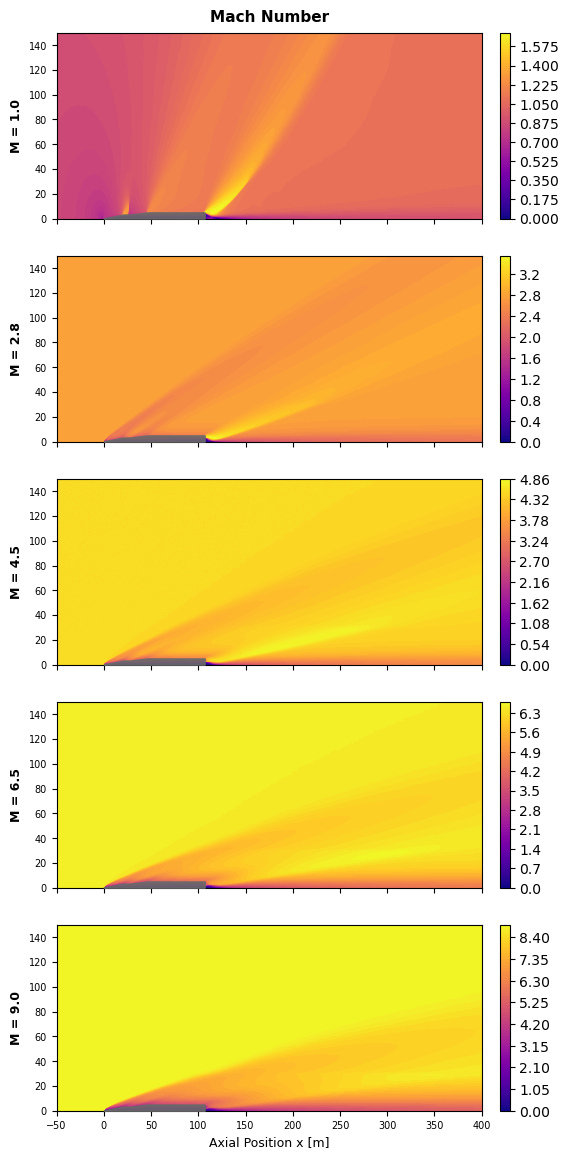

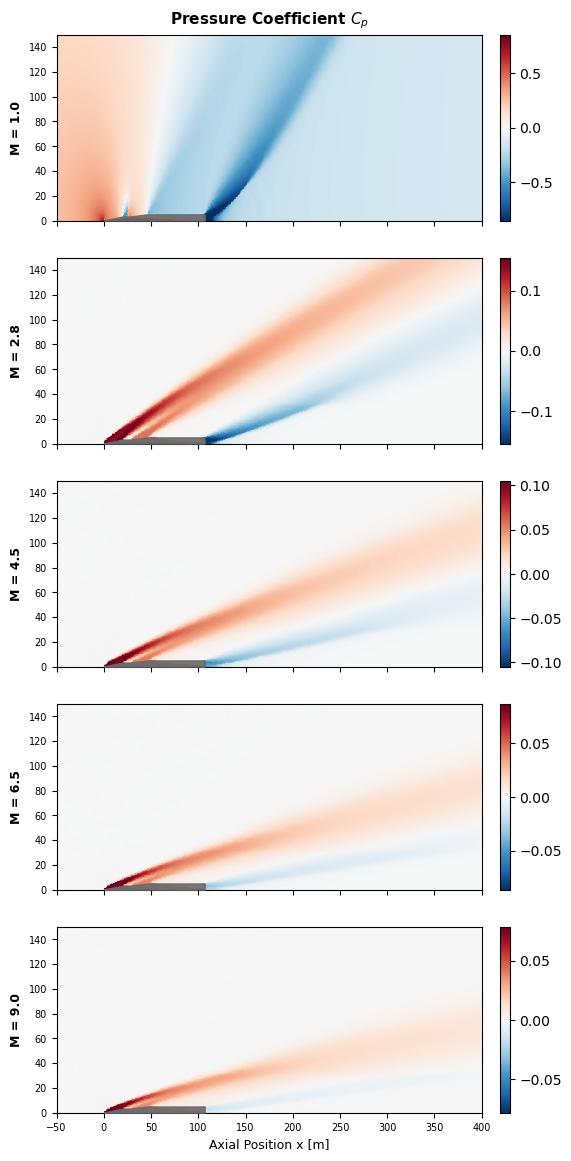

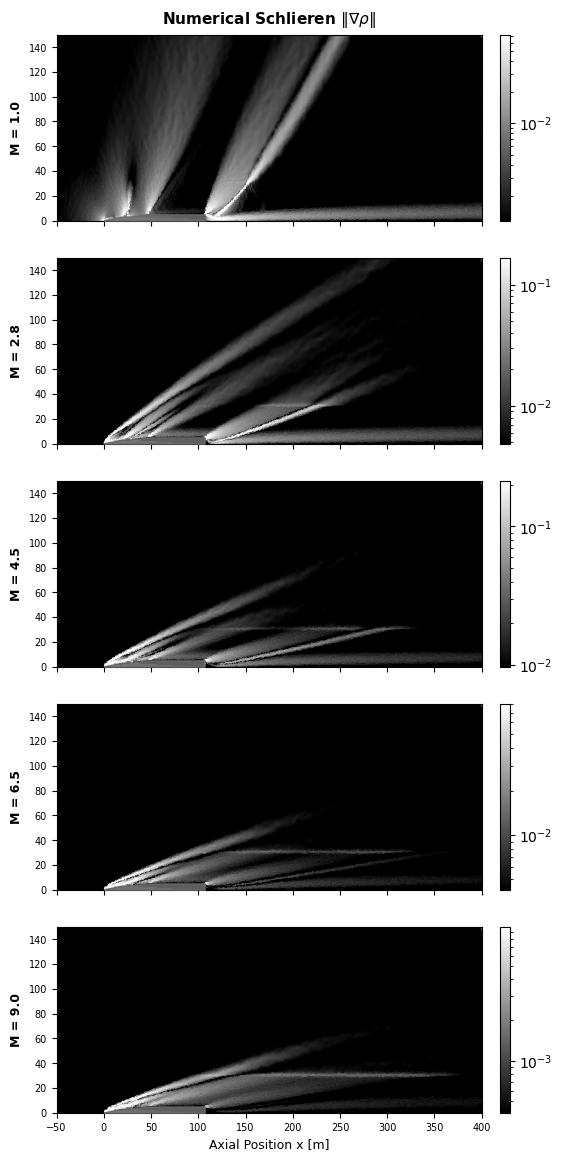

In [5]:
"""
Saturn V Flow Visualization Panel
Saves three separate column figures: Mach, Cp, Schlieren
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
from scipy.interpolate import griddata
import matplotlib.tri as tri
import os

DATA_DIR     = "."
MACH_NUMBERS = [1.0, 2.8, 4.5, 6.5, 9.0]
FILES        = [f"flow_{i}_points.csv" for i in range(1, 6)]

# Domain limits
X_MIN, X_MAX = -50, 400
Y_MIN, Y_MAX =   0, 150

# Grid resolution
NX, NY = 4800, 2000

# Saturn V body profile
BODY_X = [0, 11.7, 20.1, 28.0, 46.1, 71.1, 106.7]
BODY_R = [0.3, 1.96, 3.30, 3.30, 5.03, 5.03, 5.03]

xi = np.linspace(X_MIN, X_MAX, NX)
yi = np.linspace(Y_MIN, Y_MAX, NY)
Xi, Yi = np.meshgrid(xi, yi)

def add_body(ax):
    ax.fill_between(BODY_X, 0, BODY_R, color='dimgray', alpha=0.9, zorder=5)

def format_ax(ax, row, mach=None):
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.tick_params(labelsize=7)
    if mach:
        ax.set_ylabel(f'M = {mach}', fontsize=9, fontweight='bold')
    if row < 4:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel('Axial Position x [m]', fontsize=9)
    add_body(ax)

fig_mach,      axs_mach      = plt.subplots(5, 1, figsize=(6, 14))
fig_cp,        axs_cp        = plt.subplots(5, 1, figsize=(6, 14))
fig_schlieren, axs_schlieren = plt.subplots(5, 1, figsize=(6, 14))

for fig in [fig_mach, fig_cp, fig_schlieren]:
    fig.subplots_adjust(hspace=0.2)

axs_mach[0].set_title('Mach Number', fontsize=11, fontweight='bold', pad=8)
axs_cp[0].set_title(r'Pressure Coefficient $C_p$', fontsize=11, fontweight='bold', pad=8)
axs_schlieren[0].set_title(r'Numerical Schlieren $\|\nabla\rho\|$', fontsize=11, fontweight='bold', pad=8)

for row, (fname, mach) in enumerate(zip(FILES, MACH_NUMBERS)):
    fpath = os.path.join(DATA_DIR, fname)
    df    = pd.read_csv(fpath)

    x = df['Points_0'].values
    y = df['Points_1'].values

    mask   = (x >= X_MIN) & (x <= X_MAX) & (y >= Y_MIN) & (y <= Y_MAX)
    x, y   = x[mask], y[mask]
    points = np.column_stack([x, y])

    mach_data      = df['Mach'].values[mask]
    cp_data        = df['Pressure_Coefficient'].values[mask]
    schlieren_data = np.clip(df['Gradient_Magnitude'].values[mask], 1e-6, None)

    # Interpolate onto regular grid
    Mi  = griddata(points, mach_data, (Xi, Yi), method='linear')
    Cpi = griddata(points, cp_data,   (Xi, Yi), method='linear')

    ax = axs_mach[row]
    im = ax.contourf(Xi, Yi, Mi, levels=80, cmap='plasma')
    fig_mach.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    format_ax(ax, row, mach=mach)

    ax = axs_cp[row]
    ax.set_facecolor('white')
    triang_cp = tri.Triangulation(x, y)
    vlim = max(abs(np.nanpercentile(cp_data, 1)), abs(np.nanpercentile(cp_data, 99)))
    im = ax.tripcolor(triang_cp, cp_data, cmap='RdBu_r',
                    vmin=-vlim, vmax=vlim,
                    shading='gouraud')
    fig_cp.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    format_ax(ax, row, mach=mach)
    ax     = axs_schlieren[row]
    vmin_s = np.nanpercentile(schlieren_data, 40)
    vmax_s = np.nanpercentile(schlieren_data, 98)
    vmin_s = max(vmin_s, 1e-6)
    triang = tri.Triangulation(x, y)
    im     = ax.tripcolor(triang, schlieren_data, cmap='gray',
                          norm=LogNorm(vmin=vmin_s, vmax=vmax_s),
                          shading='gouraud')
    fig_schlieren.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    format_ax(ax, row, mach=mach)


fig_mach.savefig('mach_panel.png', dpi=600)
fig_cp.savefig('cp_panel.png', dpi=600)
fig_schlieren.savefig('schlieren_panel.png', dpi=600)

plt.show()


M = 1.0  ->  CD = 0.074289
M = 2.8  ->  CD = 0.022812
M = 4.5  ->  CD = 0.014944
M = 6.5  ->  CD = 0.012160
M = 9.0  ->  CD = 0.010965


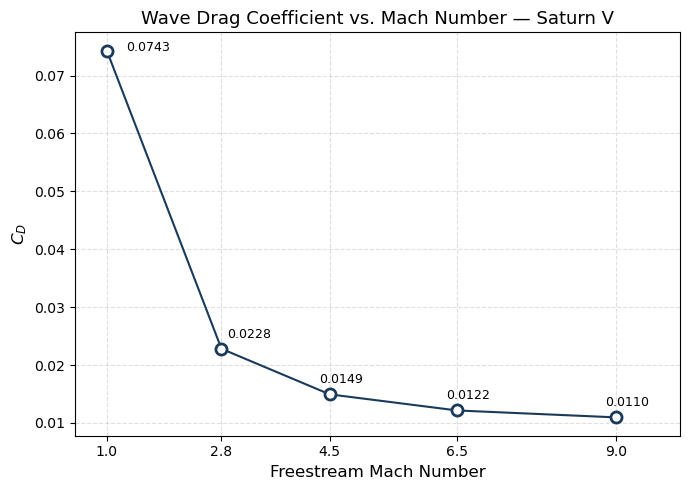

In [6]:
"""
Extract CD from SU2 history files and plot CD vs Mach number
Files: history_1.csv through history_5.csv in current directory
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

MACH_NUMBERS = [1.0, 2.8, 4.5, 6.5, 9.0]
FILES        = [f"history_{i}.csv" for i in range(1, 6)]

mach_vals, cd_vals = [], []

for fname, mach in zip(FILES, MACH_NUMBERS):
    df = pd.read_csv(fname)
    df.columns = df.columns.str.strip().str.strip('"')
    last_cd = df["CD"].iloc[-1]
    mach_vals.append(mach)
    cd_vals.append(last_cd)
    print(f"M = {mach:.1f}  ->  CD = {last_cd:.6f}")

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(mach_vals, cd_vals, 'o-', markersize=8, linewidth=1.5,
        color='#1A3A5C', markerfacecolor='white', markeredgewidth=2)

# Annotate CD values at each point
offsets = [(30, 0), (20, 8), (8, 8), (8, 8), (8, 8)]
for (mach, cd), (dx, dy) in zip(zip(mach_vals, cd_vals), offsets):
    ax.annotate(f"{cd:.4f}", xy=(mach, cd),
                textcoords="offset points", xytext=(dx, dy),
                ha="center", fontsize=9)

ax.set_xlabel("Freestream Mach Number", fontsize=12)
ax.set_ylabel("$C_D$", fontsize=12)
ax.set_title("Wave Drag Coefficient vs. Mach Number — Saturn V", fontsize=13)
ax.set_xticks(MACH_NUMBERS)
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_xlim(0.5, 10)

plt.tight_layout()
plt.savefig("cd_vs_mach.png", dpi=300)
plt.savefig("cd_vs_mach.pdf", dpi=300)
plt.show()


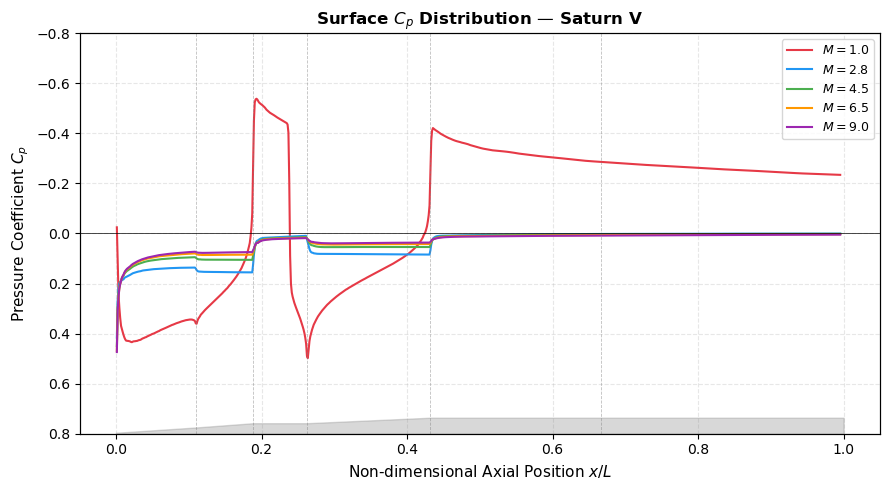

In [7]:
"""
Surface Pressure Coefficient Distribution — Saturn V
Plots Cp vs x/L for all five Mach cases on a single figure
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MACH_NUMBERS = [1.0, 2.8, 4.5, 6.5, 9.0]
FILES        = [f"surface_{i}.csv" for i in range(1, 6)]
L_REF        = 106.7  # total vehicle length [m]
BODY_X = [0, 11.7, 20.1, 28.0, 46.1, 71.1, 106.7]
BODY_R = [0.3, 1.96, 3.30, 3.30, 5.03, 5.03, 5.03]

COLORS = ['#E63946', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']


fig, ax = plt.subplots(figsize=(9, 5))


for fname, mach, color in zip(FILES, MACH_NUMBERS, COLORS):
    df = pd.read_csv(fname)
    df.columns = df.columns.str.strip().str.strip('"')

    x  = df['Points_0'].values
    cp = df['Pressure_Coefficient'].values
    cp = np.where(np.abs(cp) > 1.5, np.nan, cp)

    # Filter to vehicle body only (x = 0 to L)
    mask = (x >= 0.01) & (x <= L_REF - 0.5)
    x, cp = x[mask], cp[mask]

    # Sort by x for clean line plot
    idx = np.argsort(x)
    x, cp = x[idx], cp[idx]

    # Non-dimensionalize
    x_norm = x / L_REF

    ax.plot(x_norm, cp, label=f'$M = {mach}$', color=color, linewidth=1.5)

# Stage transition markers
stage_x = [11.7, 20.1, 28.0, 46.1, 71.1]
for sx in stage_x:
    ax.axvline(sx / L_REF, color='gray', linewidth=0.6,
               linestyle='--', alpha=0.5)

# Stage labels


ax.axhline(0, color='black', linewidth=0.5, linestyle='-')
ax.invert_yaxis()  # convention: negative Cp up
ax.set_xlabel('Non-dimensional Axial Position $x/L$', fontsize=11)
ax.set_ylabel('Pressure Coefficient $C_p$', fontsize=11)
ax.set_title('Surface $C_p$ Distribution — Saturn V', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(0.8, -0.8)  # tighter range
ax.grid(True, linestyle='--', alpha=0.3)

# Scale body profile to fit at bottom of plot
body_x_norm = [bx / L_REF for bx in BODY_X]
body_r_norm = [br / max(BODY_R) * 0.2 for br in BODY_R]  # scale to 20% of plot height

# Position at bottom of plot
y_bottom = ax.get_ylim()[0]
body_r_offset = [y_bottom + br for br in body_r_norm]

ax2 = ax.twinx()
ax2.fill_between(body_x_norm, 0, [br / max(BODY_R) for br in BODY_R],
                 color='gray', alpha=0.3, zorder=1)
ax2.set_ylim(0, 25)
ax2.set_yticks([])


plt.tight_layout()
plt.savefig('surface_cp.png', dpi=300)
plt.savefig('surface_cp.pdf', dpi=300)
plt.show()
